# Boosting Techniques

In [3]:
%pip install xgboost --quiet

Note: you may need to restart the kernel to use updated packages.


In [16]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score ,precision_score, recall_score , f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Data Loading 

In [ ]:
df = sns.load_dataset('diamonds')
df.head() 

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# Decision Tree Classifier

In [50]:
%%time
# Create feature and target variables
X = df.drop('cut',axis=1)
y = df['cut']

# Encode input features
le = LabelEncoder()
X['color'] = le.fit_transform(X['color'])
X['clarity'] = le.fit_transform(X['clarity'])

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Model 
model = DecisionTreeClassifier()

# Fit the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred , average='macro')}")
print(f"Recall : {recall_score(y_test, y_pred, average='macro')}")
print(f"F1 Score : {f1_score(y_test, y_pred, average='macro')}")

Accuracy: 0.7151464590285502
Precision : 0.7188932327908262
Recall : 0.7242661013213154
F1 Score : 0.7214979539277927
CPU times: total: 1.58 s
Wall time: 2.13 s


# XGBoost Model (Boosting)

In [51]:
%%time

# Encode target variable
le = LabelEncoder()
y = le.fit_transform(y)
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the Model 
model = XGBClassifier()

# Fit the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred, average='macro')}")
print(f"Recall : {recall_score(y_test, y_pred, average='macro')}")
print(f"F1 Score : {f1_score(y_test, y_pred, average='macro')}")

Accuracy: 0.8056173526140156
Precision : 0.816426037421739
Recall : 0.7929030247334078
F1 Score : 0.8028675486282099
CPU times: total: 11.2 s
Wall time: 4.35 s


# Random Forest Classifier (Bagging)

In [52]:
%%time
# Create model 
model = RandomForestClassifier()

# Train the model 
model.fit(X_train,y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Evaluate the Model Performance

print(f"Accuracy : {accuracy_score(y_test,y_pred)}")
print(f"Precision : {precision_score(y_test, y_pred, average='micro')}")
print(f"Recall : {recall_score(y_test, y_pred, average='micro')}")
print(f"F1 Score :{f1_score(y_test,y_pred,average='micro')}")

Accuracy : 0.7865220615498703
Precision : 0.7865220615498703
Recall : 0.7865220615498703
F1 Score :0.7865220615498703
CPU times: total: 18 s
Wall time: 19.9 s


Text(0.5, 1.0, 'Random Forest Classifier')

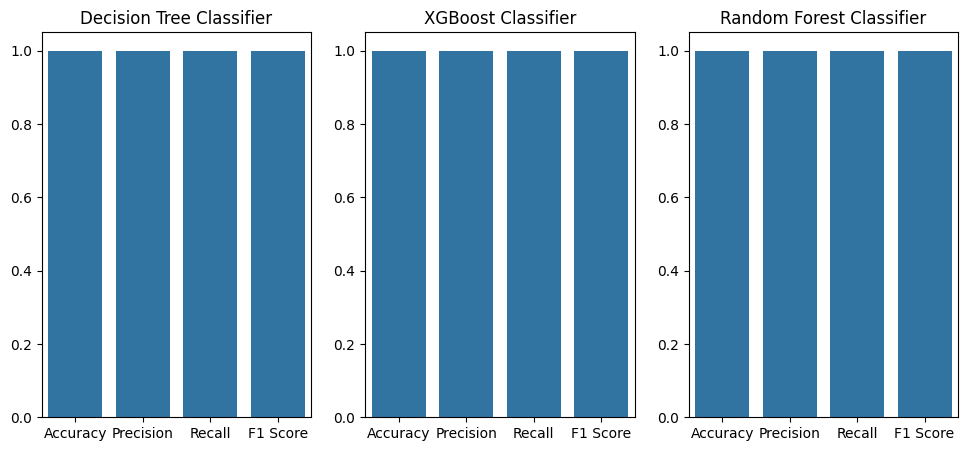

In [41]:
plt.figure(figsize=(16,5))
plt.subplot(1,4,1)
sns.barplot(x=['Accuracy','Precision','Recall','F1 Score'],y=[accuracy_score(y_test,y_pred),precision_score(y_test, y_pred, average='micro'),recall_score(y_test, y_pred, average='micro'),f1_score(y_test,y_pred,average='micro')])
plt.title('Decision Tree Classifier')
plt.subplot(1,4,2)
sns.barplot(x=['Accuracy','Precision','Recall','F1 Score'],y=[accuracy_score(y_test, y_pred),precision_score(y_test, y_pred, average='macro'),recall_score(y_test, y_pred, average='macro'),f1_score(y_test,y_pred,average='macro')])
plt.title('XGBoost Classifier')
plt.subplot(1,4,3)
sns.barplot(x=['Accuracy','Precision','Recall','F1 Score'],y=[accuracy_score(y_test, y_pred),precision_score(y_test, y_pred, average='weighted'),recall_score(y_test, y_pred, average='weighted'),f1_score(y_test,y_pred,average='weighted')])
plt.title('Random Forest Classifier')